In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from IPython.core.display import display, HTML
from matplotlib import pyplot as plt
from matplotlib import ticker as mpl_ticker
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervm7g52i
interpreter: 3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
notebook name: 2025-11-30-external-selfbb-truebb
notebook path: /home/runner/work/oee4/oee4/binder/2025-11-30-external-selfbb-truebb.ipynb
revision: bdac574
timestamp: 2026-09-21T22:42:28Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-11-30-external-selfbb-truebb"


In [5]:
df_all = []
for what, prefix in [
    ("nobb", "endeavor=16/external-competitions/stage=2+what=collated/"),
    ("selfbb", "endeavor=16/external-competitions-focalbb/stage=2+what=collated/"),
    ("truebb", "endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/"),
]:
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket("prq49")


    competitions = bucket_handle.objects.filter(Prefix=prefix)
    dfs = [
        pd.read_csv(
          f's3://prq49/{competitions.key}',
        )
        for competitions in competitions
    ]
    print(len(dfs))
    df = pd.concat(dfs, ignore_index=True)
    df["kind"] = what

    df_all.append(df)

df = pd.concat(df_all, ignore_index=True)
df = df[
    (df["Competition Series"] == 16005)
]


100
100
99


0         1.000000
2         0.247078
4         0.006954
6         0.393959
8         0.299972
            ...   
558953    0.788882
558956    0.035605
558958    0.000000
558962    0.000000
558965    0.000000
Name: Focal Prevalence, Length: 25363, dtype: float64

teeplots/2025-11-30-external-selfbb-truebb/hue=kind1+style=kind1+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-30-external-selfbb-truebb/hue=kind1+style=kind1+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


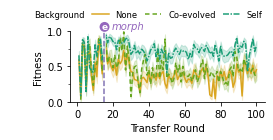

In [6]:
palette = [
    "goldenrod",
    sns.color_palette("Dark2")[1],
    sns.color_palette("Dark2")[4],
    sns.color_palette("Dark2")[3],
    sns.color_palette("Dark2")[0],
    sns.color_palette("Dark2")[5],
]

dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
display(dfx["Focal Prevalence"])

dfx["kind1"] = dfx["kind"].map({
    "nobb": "None",
    "selfbb": "Self",
    "truebb": "Co-evolved",
})
with tp.teed(
    sns.lineplot,
    data=dfx,
    x="Competition Stint",
    y="Focal Prevalence",
    hue="kind1",
    style="kind1",
    legend=False,
    dashes=["", (4, 1, 1, 1), (3, 2)],
    hue_order=["None", "", "Co-evolved", "", "Self", ""],
    palette=palette,
    teeplot_subdir=teeplot_subdir,
    teeplot_outexclude=["palette"],
) as ax:
    ax.figure.set_size_inches(3.5, 1.3)
    plt.ylim(0, 1)
    ax.set_yticks([0, 0.5, 1.0])
    ax.yaxis.set_minor_locator(mpl_ticker.FixedLocator([0.25, 0.75]))

    sns.lineplot(
        data=dfx.head(1),
        x="Competition Stint",
        y="Focal Prevalence",
        hue="kind1",
        hue_order=["Background", "None", "Co-evolved", "Self"],
        style="kind1",
        style_order=["Background", "None", "Co-evolved", "Self"],
        ax=ax,
        dashes=["","", (3, 2), (4, 1, 1, 1)],
        palette=[
            "white",
            "goldenrod",
            sns.color_palette("Dark2")[4],
            sns.color_palette("Dark2")[0],
        ],
    )

    sns.move_legend(
        ax,
        "lower center",
        bbox_to_anchor=(0.34, 1.07),
        columnspacing=0.9,
        fontsize="small",
        frameon=False,
        ncol=4,
        title=None,
    )
    sns.despine(ax=ax)
    ax.set_xlabel("Transfer Round")
    ax.set_ylabel("Fitness")
    ax.axvline(x=15, color="white", alpha=0.7, linestyle="-", linewidth=3)
    ax.axvline(x=15, color=sns.color_palette("deep")[4], linestyle="--")
    ax.text(17, 1.06, "e", ha="right", va="center", color="tab:purple", bbox=dict(facecolor="tab:purple", edgecolor="none", boxstyle="circle,pad=0.05"), fontsize=9, fontweight="semibold")
    ax.text(16.9, 1.065, "e", ha="right", va="center", color="white", fontweight="semibold", fontsize=9)
    ax.text(19, 1.065, "morph", ha="left", va="center", color="tab:purple", fontstyle="italic")
    # ax.text(16, 0.0, "15", ha="left", va="bottom", color="tab:purple")


MannwhitneyuResult(statistic=123.0, pvalue=0.2602848338696484)

(0.25510204081632654, 'small')

<ipython-input-7-1867b9cd7767>:58: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gainsboro'` for the same effect.

  sns.boxplot(
<ipython-input-7-1867b9cd7767>:89: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-7-1867b9cd7767>:106: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["None   ", "Co-evo", " Self"])


teeplots/2025-11-30-external-selfbb-truebb/hue=kind+inner=quartile+viz=violinplot+x=kind+y=focal-prevalence+ext=.pdf
teeplots/2025-11-30-external-selfbb-truebb/hue=kind+inner=quartile+viz=violinplot+x=kind+y=focal-prevalence+ext=.png


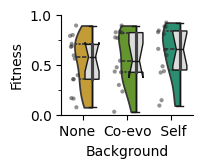

MannwhitneyuResult(statistic=7163.0, pvalue=2.681482732329822e-26)

(0.9369929691725257, 'large')

<ipython-input-7-1867b9cd7767>:58: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gainsboro'` for the same effect.

  sns.boxplot(
<ipython-input-7-1867b9cd7767>:89: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-7-1867b9cd7767>:106: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["None   ", "Co-evo", " Self"])
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-30-external-selfbb-truebb/hue=kind+inner=quartile+viz=violinplot+x=kind+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(


teeplots/2025-11-30-external-selfbb-truebb/hue=kind+inner=quartile+viz=violinplot+x=kind+y=focal-prevalence+ext=.pdf
teeplots/2025-11-30-external-selfbb-truebb/hue=kind+inner=quartile+viz=violinplot+x=kind+y=focal-prevalence+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-30-external-selfbb-truebb/hue=kind+inner=quartile+viz=violinplot+x=kind+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


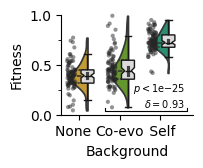

In [7]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
dfx["when"] = dfx["Competition Stint"] > 14

for when, dfx_ in dfx.groupby("when"):
    data = dfx_.groupby(
        ["when", "kind", "Competition Stint"],
        as_index=False,
    )["Focal Prevalence"].mean().reset_index(drop=True)
    display(
        scipy_stats.mannwhitneyu(
            data.loc[
                data["kind"] == "selfbb",
                "Focal Prevalence",
            ],
            data.loc[
                data["kind"] == "nobb",
                "Focal Prevalence",
            ],
            alternative="two-sided",
        ),
    )
    display(
        cliffs_delta(
            data.loc[
                data["kind"] == "selfbb",
                "Focal Prevalence",
            ],
            data.loc[
                data["kind"] == "nobb",
                "Focal Prevalence",
            ],
        ),
    )

    data["kind1"] = data["kind"]
    data["one"] = 1
    display(HTML(f"<h3>{when=}</h3>"))
    with tp.teed(
        sns.violinplot,
        data=data,
        x="kind",
        y="Focal Prevalence",
        hue="kind",
        order=["nobb", "truebb", "selfbb"],
        hue_order=["nobb", "", "truebb", "", "selfbb", ""],
        cut=0,
        gap=0.5,
        inner="quartile",
        palette=palette,
        split=True,
        teeplot_subdir=teeplot_subdir,
        teeplot_outexclude=["palette"],
    ) as ax:
        ax.figure.set_size_inches(1.7, 1.3)
        sns.boxplot(
            data=data,
            x="kind",
            y="Focal Prevalence",
            hue="one",
            color="gainsboro",
            # alpha=0.3,
            order=["nobb", "truebb", "selfbb"],
            gap=0.2,
            hue_order=[2, 1],
            dodge=True,
            legend=False,
            notch=True,
            showfliers=False,
        )
        sns.barplot(
            data=data,
            x="kind",
            y="Focal Prevalence",
            hue="one",
            hue_order=[2, 1],
            alpha=0.0,
            ax=ax,
            clip_on=False,
            dodge=True,
            estimator=np.median,
            gap=0.2,
            legend=False,
            order=["nobb", "truebb", "selfbb"],
        )
        np.random.seed(1)
        sns.stripplot(
            data=data,
            x="kind",
            y="Focal Prevalence",
            hue="one",
            color="black",
            clip_on=False,
            hue_order=[1, 2],
            alpha=0.5,
            dodge=True,
            jitter=0.2,
            legend=False,
            size=3,
            order=["nobb", "truebb", "selfbb"],
        )
        plt.ylim(0, 1)
        ax.set_xlabel("Background")
        ax.set_xticklabels(["None   ", "Co-evo", " Self"])
        ax.set_ylabel("Fitness")
        ax.set_yticks([0, 0.5, 1.0])
        ax.yaxis.set_minor_locator(mpl_ticker.FixedLocator([0.25, 0.75]))
        sns.despine(ax=ax)
        if when:
            ax.text(
                0.94,
                0.2,
                "$p < 1\mathrm{e}{-25}$\n$\delta=0.93$",
                ha="right",
                va="center",
                size=7,
                transform=ax.transAxes,
            )
            brace_y = 0.04
            arm_depth = 0.03
            ax.plot(
                [0.63, 0.63, 2.66, 2.66],
                [brace_y + arm_depth, brace_y, brace_y, brace_y + arm_depth],
                linewidth=0.8,
                clip_on=False,
                color="black",
                zorder=-1000,
            )
